<a href="https://www.kaggle.com/code/mrafraim/dl-day-55-detection-fundamentals?scriptVersionId=317313080" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Day 55: Detection Fundamentals
Classification vs Detection • Bounding Boxes • IoU • NMS • mAP

Welcome to Day 55!

What You’ll Learn Today

1. Classification vs Detection (core shift)
2. What a bounding box really represents
3. Intersection over Union (IoU)
4. Non-Maximum Suppression (NMS)
5. mAP (mean Average Precision)
6. How detection systems actually behave

If you found this notebook helpful, your **<b style="color:skyblue;">UPVOTE</b>** would be greatly appreciated! It helps others discover the work and supports continuous improvement.

---

# Classification vs Detection (core shift)

## Classification

Input → Image  
Output → Single label  

Example:
Image → "Cat"

## Detection

Input → Image  
Output → Multiple objects + locations  

Example:

Image →  
✔ Cat at (x1,y1,x2,y2)  
✔ Dog at (x1,y1,x2,y2)

## Core Difference

Classification:
- “What is in the image?”

Detection:
- “What is in the image AND where is it?”

## Why This Is Harder

Now the model must learn:

1. Object classification  
2. Object localization  
3. Multiple objects per image  

→ This is a **multi-task problem**

# Bounding Boxes


## What is a Bounding Box?

A bounding box is a rectangle drawn around an object in an image to define:

- Where the object is
- How big the object is

## Format 1: Corner Coordinates (Most intuitive)

A box is defined using two opposite corners:

(x_min, y_min, x_max, y_max)

**Example:**

Top-left corner:

(50, 100)

Bottom-right corner:

(200, 300)

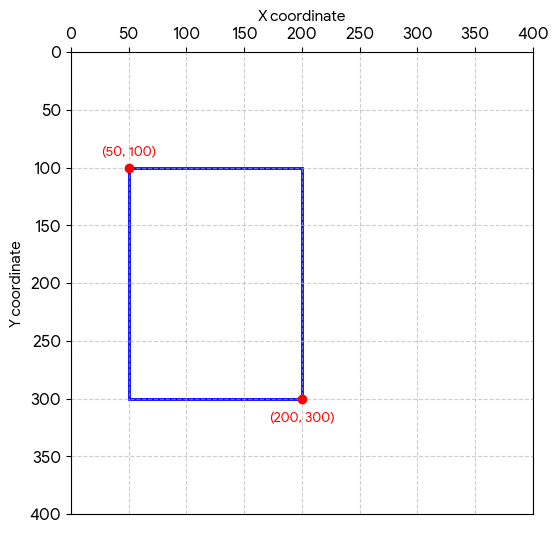

## Format 2: Center-based Representation (Used in ML models)

Instead of corners, we describe the box using:

(x_center, y_center, width, height)

**Example:**

x_center = 125<br>
y_center = 200<br>
width = 150<br>
height = 200

Meaning:
- Center of object is at (125, 200)
- Object spans 150 units wide and 200 units tall


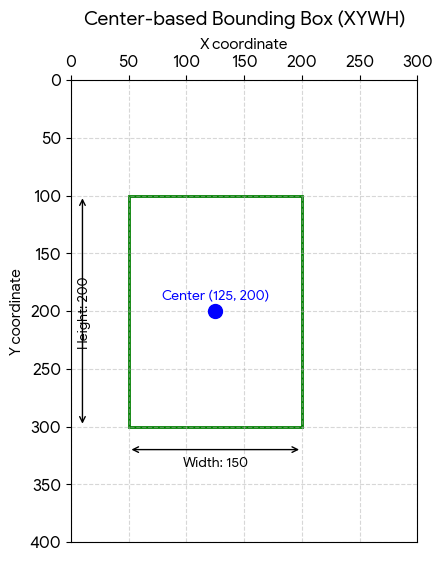

## Key Insight (Very Important)

Bounding box prediction is NOT classification.

| Task | Type |
|------|------|
| What object is it? | Classification |
| Where is it located? | Regression |


> Object Detection = Classification + Regression

## Mental Model

Think in two steps:

**Identify object**
→ Cat / Dog / Car

**Locate object**
→ Draw rectangle using coordinates

# Intersection over Union (IoU)

You predicted a box.

But the model needs to answer:

"How GOOD is this box compared to the actual object?"

So we need a **score of overlap quality**.

## Core Idea

Take two boxes:

- 🟩 Ground Truth (actual object)
- 🟥 Predicted Box (model output)

Now ask:

👉 How much do they overlap?

**Step 1: Intersection (Common Area)**

This is the overlapping region:


Intersection = shared area between two boxes


If they barely touch → small  
If they align well → large  

**Step 2: Union (Total Covered Area)**

This is everything covered by both boxes:


Union = area of both boxes combined (no double counting)

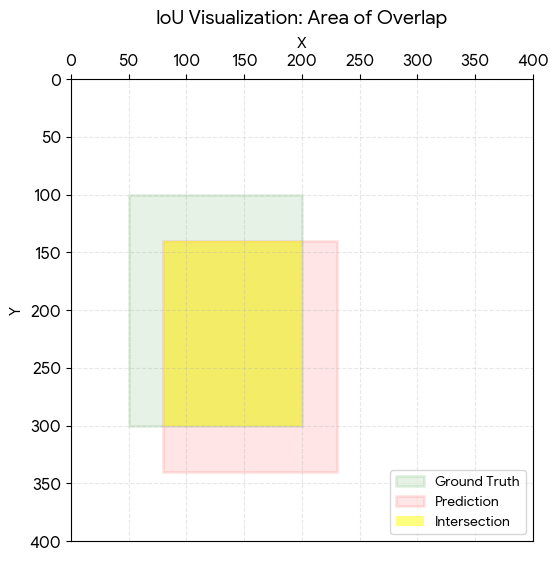

### Final Formula

$$
IoU = \frac{Intersection}{Union}
$$

## Visual Thinking

**Case 1: Perfect match**

- Intersection = full box  
- Union = same box  

👉 IoU = 1.0

**Case 2: Partial overlap**

- Intersection = medium  
- Union = large  

👉 IoU ≈ 0.5–0.7

**Case 3: No overlap**

- Intersection = 0  
- Union = large  

👉 IoU = 0

## Real Practice

Typical thresholds:

- 0.5 → lenient  
- 0.75 → strict  
- COCO → uses multiple thresholds (0.5 to 0.95)

# Non-Maximum Suppression (NMS)

## The Real Problem (What the model actually does) 

An object detector doesn’t “see one object → output one box”.

It scans MANY regions and says:

👉 “This looks like a dog” (again and again)

So you get:

- Box A → dog (0.90)
- Box B → dog (0.85)
- Box C → dog (0.70)

👉 All pointing to the SAME dog


## Why this happens (core truth)

Detection models are:

👉 **over-generative by design**

They prefer:
- multiple guesses ✔

over

- missing an object ❌

So duplicates are expected, not a bug.

## What NMS actually does

**Non-Maximum Suppression (NMS)** is a cleanup technique used to eliminate redundant, overlapping bounding boxes so that only the best one remains for each object.

- **Non-Maximum:** Refers to all the "loser" boxes,the ones that have lower confidence scores than the best box in a specific area.
- **Suppression:** Means to ignore, hide, or delete.

NMS = **“keep the best guess, kill the rest”**

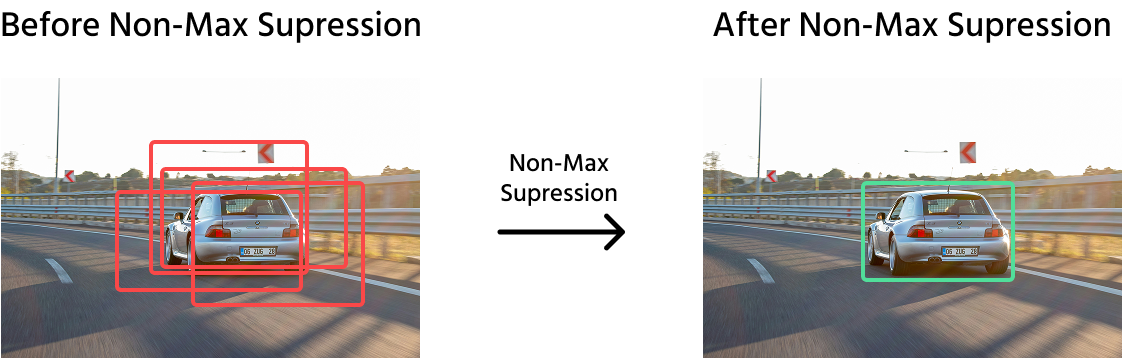


## Step-by-step (with intuition)

### Step 1: Pick the strongest box

Take highest confidence:

Box A (0.90)

👉 This becomes your “trusted” box

### Step 2: Compare overlap (IoU)

Now compare Box A with others:

- Box B → overlaps heavily  
- Box C → overlaps heavily  

👉 These are likely duplicates

### Step 3: Remove duplicates

If:

IoU(Box A, Box B) > threshold

👉 Remove Box B

Same for C

### Step 4: Repeat

Move to next remaining box (if any)

### Final Result

From:
- A, B, C ❌

To:
- A ✔ (only one box remains)

## The Trade-Off

### Case 1: Low IoU threshold (e.g., 0.3)

👉 Very strict

- Removes boxes even with small overlap
- Risk: deletes VALID nearby objects

Example:
- two dogs standing close → one disappears ❌


### Case 2: High IoU threshold (e.g., 0.8)

👉 Very lenient

- Keeps more boxes
- Risk: duplicates remain

Example:
- same dog → 2 boxes still shown ❌


## Simple Analogy

Imagine 5 people pointing at the same dog:

- “Dog here!”  
- “No, here!”  
- “Actually here!”

NMS says:

👉 “Only the most confident person speaks. Others stay quiet.”

## Important Reality (Production insight)

- NMS is a post-processing step
- It is NOT learned by the model
- It’s manually tuned

That means:

👉 wrong threshold = bad results

NMS =

> “Select the best box and suppress all overlapping duplicates using IoU”

**TO BE CONTINUE>>>**

---
<p style="text-align:center; color:skyblue; font-size:18px;">
© 2026 Mostafizur Rahman
</p>
